<a href="https://colab.research.google.com/github/brandon5254/Data_Science/blob/main/Pokemon.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Trabajo Gestion Analisis de datos cluster

Integrantes:
Santiago Adalberto Pabon Alvear

Brandon Eduardo Tobar Sanchez

Jaime Andres Cardona Montero

In [ ]:
# Librerías básicas
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics  import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Preprocesamiento y escalado
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Modelos de Clustering
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering

# Evaluación del Clustering
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Reducción de dimensionalidad (opcional para visualización)
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage

In [ ]:
import kagglehub
import pandas as pd

# Descargar el dataset
path = kagglehub.dataset_download("abcsds/pokemon")

# Mostrar la ruta del dataset
print("Path to dataset files:", path)

# Cargar el archivo en un DataFrame
df = pd.read_csv(f"{path}/Pokemon.csv")  #

# Mostrar las primeras filas
df.head()

Path to dataset files: /kaggle/input/pokemon


,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False


In [ ]:
# Ver estructura general
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   #           800 non-null    int64 
 1   Name        800 non-null    object
 2   Type 1      800 non-null    object
 3   Type 2      414 non-null    object
 4   Total       800 non-null    int64 
 5   HP          800 non-null    int64 
 6   Attack      800 non-null    int64 
 7   Defense     800 non-null    int64 
 8   Sp. Atk     800 non-null    int64 
 9   Sp. Def     800 non-null    int64 
 10  Speed       800 non-null    int64 
 11  Generation  800 non-null    int64 
 12  Legendary   800 non-null    bool  
dtypes: bool(1), int64(9), object(3)
memory usage: 75.9+ KB


In [ ]:
# Ver estadísticas básicas
df.describe()

,#,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation
count,800.000000,800.00000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.00000
mean,362.813750,435.10250,69.258750,79.001250,73.842500,72.820000,71.902500,68.277500,3.32375
std,208.343798,119.96304,25.534669,32.457366,31.183501,32.722294,27.828916,29.060474,1.66129
min,1.000000,180.00000,1.000000,5.000000,5.000000,10.000000,20.000000,5.000000,1.00000
25%,184.750000,330.00000,50.000000,55.000000,50.000000,49.750000,50.000000,45.000000,2.00000
50%,364.500000,450.00000,65.000000,75.000000,70.000000,65.000000,70.000000,65.000000,3.00000
75%,539.250000,515.00000,80.000000,100.000000,90.000000,95.000000,90.000000,90.000000,5.00000
max,721.000000,780.00000,255.000000,190.000000,230.000000,194.000000,230.000000,180.000000,6.00000


In [ ]:
# Ver si hay valores nulos
df.isnull().sum()

,0
#,0
Name,0
Type 1,0
Type 2,386
Total,0
HP,0
Attack,0
Defense,0
Sp. Atk,0
Sp. Def,0


In [ ]:
df['Type 2'].fillna('None', inplace=True)


<ipython-input-6-0af3e49bb646>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Type 2'].fillna('None', inplace=True)


In [ ]:
df.isnull().sum()

,0
#,0
Name,0
Type 1,0
Type 2,0
Total,0
HP,0
Attack,0
Defense,0
Sp. Atk,0
Sp. Def,0


In [ ]:
# Eliminar columnas que no vamos a usar por ahora
df_clean = df.drop(columns=['#', 'Name'])

In [ ]:
# Codificar 'Type 1' y 'Type 2'
df_encoded = pd.get_dummies(df_clean, columns=['Type 1', 'Type 2'])

df_encoded.head()


,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary,Type 1_Bug,...,Type 2_Grass,Type 2_Ground,Type 2_Ice,Type 2_None,Type 2_Normal,Type 2_Poison,Type 2_Psychic,Type 2_Rock,Type 2_Steel,Type 2_Water
0,318,45,49,49,65,65,45,1,False,False,...,False,False,False,False,False,True,False,False,False,False
1,405,60,62,63,80,80,60,1,False,False,...,False,False,False,False,False,True,False,False,False,False
2,525,80,82,83,100,100,80,1,False,False,...,False,False,False,False,False,True,False,False,False,False
3,625,80,100,123,122,120,80,1,False,False,...,False,False,False,False,False,True,False,False,False,False
4,309,39,52,43,60,50,65,1,False,False,...,False,False,False,True,False,False,False,False,False,False


In [ ]:

# Columnas que queremos escalar (todas las numéricas)
stat_cols = ['HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed', 'Total']

scaler = StandardScaler()
df_encoded[stat_cols] = scaler.fit_transform(df_encoded[stat_cols])

df_encoded.head()


,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary,Type 1_Bug,...,Type 2_Grass,Type 2_Ground,Type 2_Ice,Type 2_None,Type 2_Normal,Type 2_Poison,Type 2_Psychic,Type 2_Rock,Type 2_Steel,Type 2_Water
0,-0.976765,-0.950626,-0.924906,-0.797154,-0.239130,-0.248189,-0.801503,1,False,False,...,False,False,False,False,False,True,False,False,False,False
1,-0.251088,-0.362822,-0.524130,-0.347917,0.219560,0.291156,-0.285015,1,False,False,...,False,False,False,False,False,True,False,False,False,False
2,0.749845,0.420917,0.092448,0.293849,0.831146,1.010283,0.403635,1,False,False,...,False,False,False,False,False,True,False,False,False,False
3,1.583957,0.420917,0.647369,1.577381,1.503891,1.729409,0.403635,1,False,False,...,False,False,False,False,False,True,False,False,False,False
4,-1.051836,-1.185748,-0.832419,-0.989683,-0.392027,-0.787533,-0.112853,1,False,False,...,False,False,False,True,False,False,False,False,False,False


In [ ]:

# Seleccionamos solo las columnas numéricas relacionadas con stats
features = ['HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed']
X = df[features]

# Escalamos los datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


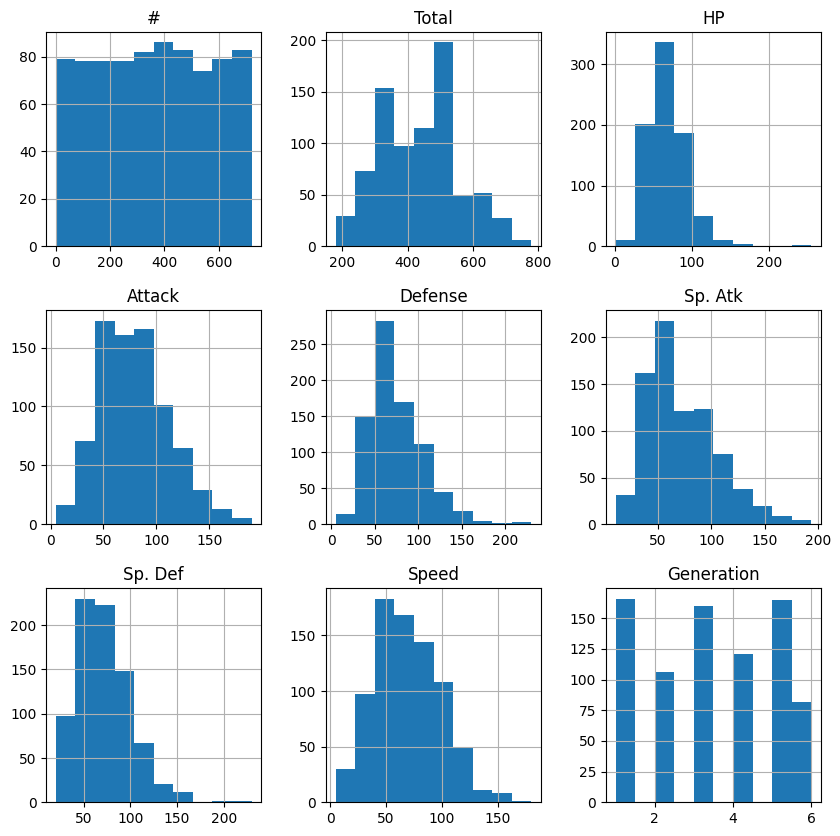

In [ ]:
df.hist(figsize=(10, 10))
plt.show()

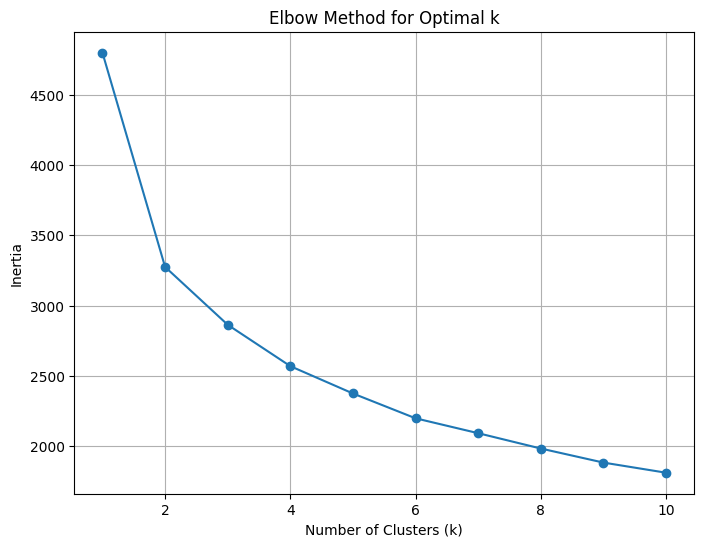

In [ ]:
# en df aplicamos el metodo del codo  para agrupar HP, Attack, Defense,Sp. Atk	,Sp. Def,Speed
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Assuming 'X_scaled' from the provided code holds the scaled features
# If not, replace with your scaled data
X = X_scaled

# Calculate inertia for different k values
inertia = []
k_values = range(1, 11)  # Test k values from 1 to 10
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=0)  # Set random_state for reproducibility
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

# Plot the elbow method
plt.figure(figsize=(8, 6))
plt.plot(k_values, inertia, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()


In [ ]:
# creamos un  clustering KMeans sobre df, manejando columnas no numéricas
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Asegúrate de trabajar solo con columnas numéricas
df_numeric = df.select_dtypes(include=['number'])

# Determinar k óptimo (ajustar si es necesario)
optimal_k = 2

# Aplicar KMeans clustering
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
df['cluster'] = kmeans.fit_predict(df_numeric)

# Reducción de dimensiones si hay más de 2 columnas numéricas (opcional, sin graficar)
if df_numeric.shape[1] > 2:
    pca = PCA(n_components=2)
    df_pca = pca.fit_transform(df_numeric)
    # Si quieres guardar los componentes:
    df['PCA1'] = df_pca[:, 0]
    df['PCA2'] = df_pca[:, 1]
elif df_numeric.shape[1] == 2:
    # Nada adicional, ya se puede usar directamente si se quiere graficar después
    pass
else:
    print("No hay suficientes columnas numéricas para reducción de dimensiones.")

# Mostrar los primeros registros con su cluster asignado
df.head()


,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary,cluster,PCA1,PCA2
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False,0,-374.269553,-81.679380
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False,0,-362.085759,11.263806
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False,0,-345.637716,139.577884
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False,0,-332.470041,247.586949
4,4,Charmander,Fire,None,309,39,52,43,60,50,65,1,False,0,-372.683781,-91.953196


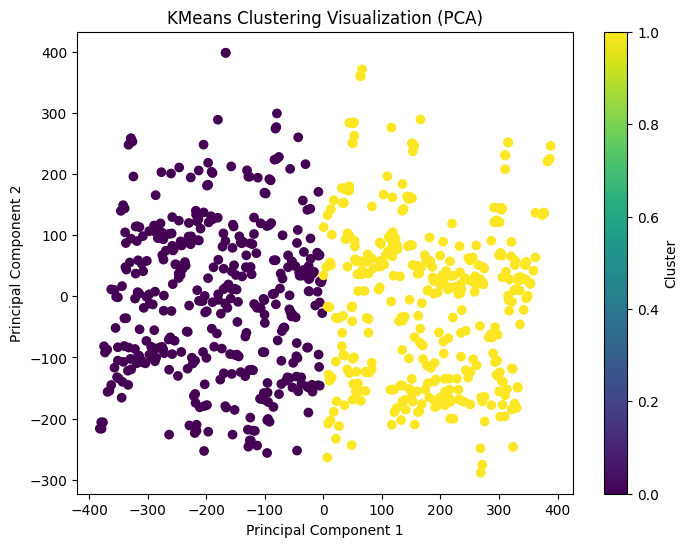

In [ ]:
#grafico del cluster

import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Assuming df and df_numeric are defined as in the previous code

# Visualization using the first two principal components (if applicable)
if df_numeric.shape[1] > 2:
    pca = PCA(n_components=2)
    df_pca = pca.fit_transform(df_numeric)
    plt.figure(figsize=(8, 6))
    plt.scatter(df_pca[:, 0], df_pca[:, 1], c=df['cluster'], cmap='viridis')
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.title('KMeans Clustering Visualization (PCA)')
    plt.colorbar(label='Cluster')
    plt.show()
elif df_numeric.shape[1] == 2:
    plt.scatter(df_numeric.iloc[:, 0], df_numeric.iloc[:, 1], c=df['cluster'])
    plt.xlabel(df_numeric.columns[0])
    plt.ylabel(df_numeric.columns[1])
    plt.title('KMeans Clustering Visualization')
    plt.show()
else:
    print("Cannot plot less than 2 dimensions")


In [ ]:
# utilizamos la metrica sluette score

# Calculate Silhouette Score
silhouette_avg = silhouette_score(df_numeric, df['cluster'])
print(f"Silhouette Score: {silhouette_avg}")

# ... (rest of your existing code) ...


Silhouette Score: 0.42623032756837453


Legendary  False  True 
cluster                
0            387     11
1            348     54


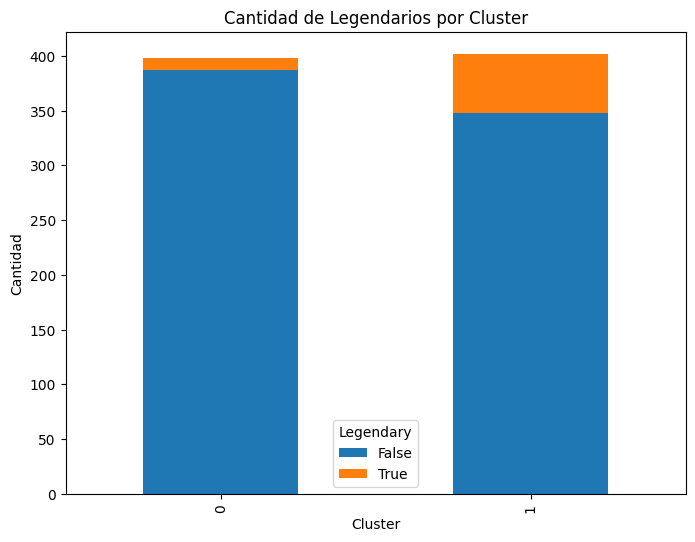

In [ ]:
# Contamos cuántos legendarios hay por cluster

import matplotlib.pyplot as plt
from sklearn.decomposition import PCA


# Contamos cuántos legendarios hay por cluster
legendary_counts = df.groupby('cluster')['Legendary'].value_counts().unstack(fill_value=0)
print(legendary_counts)

# Visualización de la cantidad de legendarios por cluster (opcional)
legendary_counts.plot(kind='bar', stacked=True, figsize=(8, 6))
plt.title('Cantidad de Legendarios por Cluster')
plt.xlabel('Cluster')
plt.ylabel('Cantidad')
plt.show()


In [ ]:
from sklearn.model_selection import train_test_split

# Features y target
X = df[['HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed']]
y = df['Legendary']

# División entrenamiento/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)


              precision    recall  f1-score   support

       False       0.99      0.96      0.97       221
        True       0.65      0.89      0.76        19

    accuracy                           0.95       240
   macro avg       0.82      0.93      0.87       240
weighted avg       0.96      0.95      0.96       240



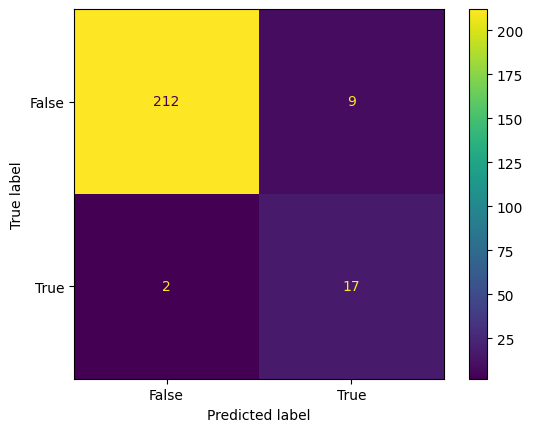

In [ ]:
# Aplicar SMOTE para balancear los datos
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Inicializar y entrenar el clasificador RandomForest
random_forest = RandomForestClassifier(random_state=42)
random_forest.fit(X_train_resampled, y_train_resampled)

# Hacer predicciones en el conjunto de prueba
y_pred = random_forest.predict(X_test)

# Evaluar el modelo
print(classification_report(y_test, y_pred))

# Métricas
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=random_forest.classes_)
disp.plot()


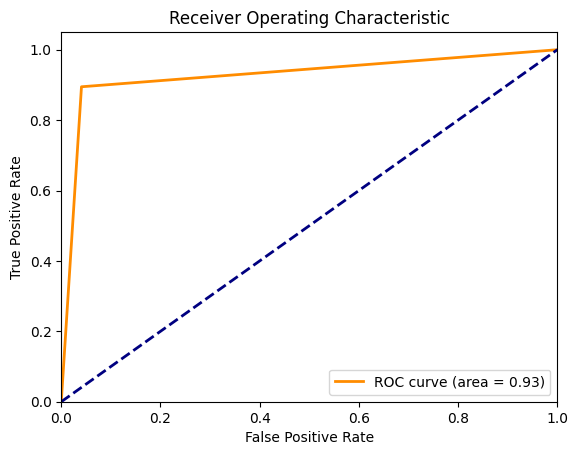

In [ ]:
#grafico de  la curva roc

import matplotlib.pyplot as plt
# Assuming y_test and y_pred are defined from your previous code (RandomForestClassifier predictions)
from sklearn.metrics import roc_curve, auc

# Calculate the ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred)

# Calculate the AUC
roc_auc = auc(fpr, tpr)

# Plot the ROC curve
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()


In [ ]:
import joblib

# Guarda el modelo
joblib.dump(random_forest, 'modelo_pokemon.pkl')

# Cargar el modelo
rf_cargado = joblib.load('modelo_pokemon.pkl')


In [ ]:
print(y.value_counts())


Legendary
False    735
True      65
Name: count, dtype: int64


Conclusion del Analisis





 En este trabajo se realizó un análisis exploratorio y modelado de datos utilizando el dataset de Pokémon, aplicando técnicas de clustering y clasificación supervisada.

Primero, se aplicó el algoritmo KMeans para agrupar a los Pokémon en clústeres basados en sus atributos estadísticos (HP, Attack, Defense, Sp. Atk, Sp. Def y Speed). Mediante el método del codo y el análisis de la métrica Silhouette Score, se determinó que el valor óptimo de k era 2, lo cual permitió diferenciar grupos de Pokémon con características similares. La visualización en componentes principales (PCA) mostró una clara separación entre los clústeres, lo cual fue consistente con la distribución de Pokémon legendarios dentro de cada grupo.

Posteriormente, se abordó la tarea de clasificación binaria para predecir si un Pokémon es legendario o no. Para ello, se utilizó el algoritmo Random Forest, precedido por el balanceo del conjunto de entrenamiento mediante SMOTE, técnica que permitió abordar el desbalance de clases presente en el dataset original. El modelo alcanzó métricas sólidas según el classification report, destacándose en precisión, recall y F1-score. La matriz de confusión y la curva ROC confirmaron un buen rendimiento general, evidenciando una capacidad adecuada del modelo para distinguir entre Pokémon legendarios y no legendarios.

En conclusión, la combinación de técnicas no supervisadas y supervisadas, junto con un adecuado preprocesamiento y balanceo de datos, permitió extraer patrones relevantes del dataset y construir un clasificador eficaz. Este enfoque podría ser útil en otros contextos donde se requiera agrupar entidades similares y luego predecir características específicas basadas en esos grupos y atributos cuantificables.